<a href="https://colab.research.google.com/github/Vladikadze/Variational-Sparse-Gaussian-Process-with-a-Nonparametric-Prior/blob/main/sparce_gp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import jax
from jax import numpy as jnp
from jax import grad, jit, vmap
from jax import random

First I want to represent a single Gaussian Process on the data

I want to predict NSM based on the date

In [3]:
df = pd.read_csv('/content/Steel_industry_data.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
import pandas as pd
import jax.numpy as jnp

# ── 1. Parse dates and sort chronologically ───────────────────────────────────
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values('date').reset_index(drop=True)

# ── 2. Stratify by weekday (fit weekday model first) ─────────────────────────
df_weekday = df[df['WeekStatus'] == 'Weekday'].reset_index(drop=True)
df_weekend = df[df['WeekStatus'] == 'Weekend'].reset_index(drop=True)

# ── 3. Temporal train/test split on weekdays ──────────────────────────────────
unique_dates = df_weekday['date'].dt.date.unique()  # sorted, one entry per day
split_date   = unique_dates[int(0.8 * len(unique_dates))]  # 80th percentile date

train_df = df_weekday[df_weekday['date'].dt.date < split_date].reset_index(drop=True)
test_df  = df_weekday[df_weekday['date'].dt.date >= split_date].reset_index(drop=True)

print(f"Train: {len(train_df)} rows | {train_df['date'].dt.date.nunique()} days")
print(f"Test:  {len(test_df)} rows  | {test_df['date'].dt.date.nunique()} days")
print(f"Split date: {split_date}")

# ── 4. Extract X (time of day) and Y (energy) ────────────────────────────────
X_train_raw = train_df['NSM'].values / 86400.0   # normalize to [0, 1]
X_test_raw  = test_df['NSM'].values  / 86400.0

Y_train_raw = train_df['Usage_kWh'].values
Y_test_raw  = test_df['Usage_kWh'].values

# ── 5. Standardize Y using train statistics only ──────────────────────────────
Y_mean = Y_train_raw.mean()
Y_std  = Y_train_raw.std()

X_train = jnp.asarray(X_train_raw)
X_test  = jnp.asarray(X_test_raw)

Y_train = jnp.asarray((Y_train_raw - Y_mean) / Y_std)
Y_test  = jnp.asarray((Y_test_raw  - Y_mean) / Y_std)  # same stats, not recomputed

# ── 6. Keep Load_Type for post-hoc validation only (never used in training) ───
load_type_train = train_df['Load_Type'].values
load_type_test  = test_df['Load_Type'].values
load_type_all   = df_weekday['Load_Type'].values

# ── 7. Full weekday arrays for component assignment validation ─────────────────
X_all = jnp.asarray(df_weekday['NSM'].values / 86400.0)
Y_all = jnp.asarray((df_weekday['Usage_kWh'].values - Y_mean) / Y_std)

# ── 8. Sanity checks ──────────────────────────────────────────────────────────
assert X_train.shape == Y_train.shape
assert X_test.shape  == Y_test.shape
assert float(jnp.min(X_train)) >= 0.0 and float(jnp.max(X_train)) <= 1.0
assert abs(float(jnp.mean(Y_train))) < 0.1   # should be ~0 after standardization
assert abs(float(jnp.std(Y_train))  - 1.0) < 0.1  # should be ~1

print(f"\nX_train: {X_train.shape}, range [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"Y_train: {Y_train.shape}, mean {Y_train.mean():.3f}, std {Y_train.std():.3f}")
print(f"X_test:  {X_test.shape}")
print(f"Y_test:  {Y_test.shape}")
print(f"\nLoad types in train: {pd.Series(load_type_train).value_counts().to_dict()}")
print(f"Load types in test:  {pd.Series(load_type_test).value_counts().to_dict()}")

Train: 19968 rows | 208 days
Test:  5088 rows  | 53 days
Split date: 2018-10-18

X_train: (19968,), range [0.000, 0.990]
Y_train: (19968,), mean -0.000, std 1.000
X_test:  (5088,)
Y_test:  (5088,)

Load types in train: {'Light_Load': 8936, 'Medium_Load': 6304, 'Maximum_Load': 4728}
Load types in test:  {'Light_Load': 2232, 'Medium_Load': 1632, 'Maximum_Load': 1224}


In [5]:
# Extract the date part from the 'date' column
df['day'] = df['date'].dt.date

# Calculate the variance of 'Usage_kWh' for each day
daily_variance_Y = df.groupby('day')['Usage_kWh'].var().reset_index()

# Display the results
print("Variance of Y (Usage_kWh) over days:")
display(daily_variance_Y.head())
print(f"Mean of daily Usage_kWh variance: {daily_variance_Y['Usage_kWh'].mean():.2f}")

Variance of Y (Usage_kWh) over days:


,day,Usage_kWh
0,2018-01-01,0.085524
1,2018-01-02,2146.579963
2,2018-01-03,1458.673208
3,2018-01-04,2724.591862
4,2018-01-05,2502.837954


Mean of daily Usage_kWh variance: 890.69


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


### Training Data: X_train vs Y_train

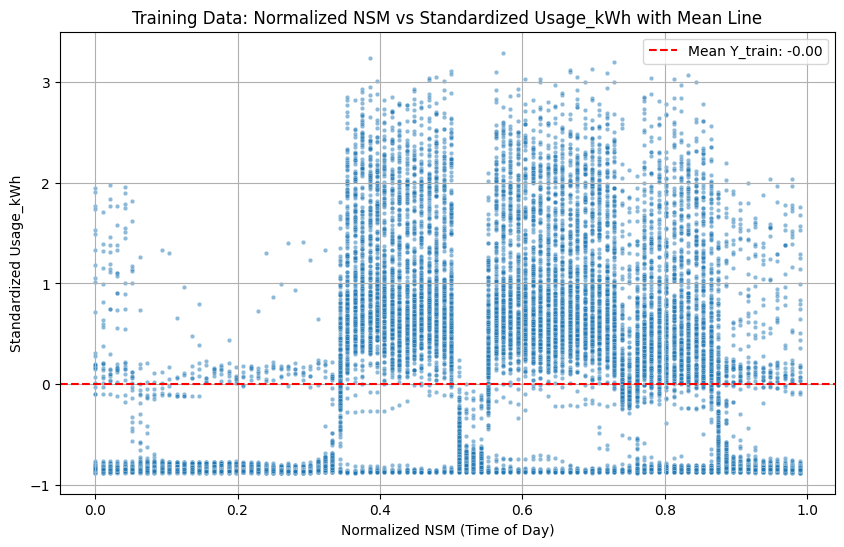

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train, y=Y_train, alpha=0.5, s=10)
plt.axhline(y=Y_train.mean(), color='r', linestyle='--', label=f'Mean Y_train: {Y_train.mean():.2f}')
plt.title('Training Data: Normalized NSM vs Standardized Usage_kWh with Mean Line')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Standardized Usage_kWh')
plt.grid(True)
plt.legend()
plt.show()


### Testing Data: X_test vs Y_test

### Mean Usage_kWh per Time of Day (NSM) for Training Data

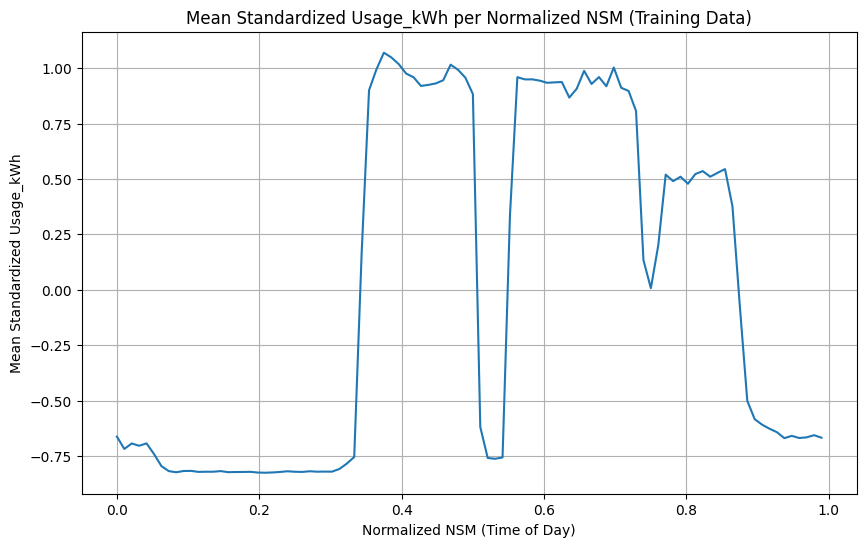

In [8]:
mean_Y_train_by_X = pd.DataFrame({'X_train': X_train, 'Y_train': Y_train}).groupby('X_train')['Y_train'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='X_train', y='Y_train', data=mean_Y_train_by_X)
plt.title('Mean Standardized Usage_kWh per Normalized NSM (Training Data)')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Mean Standardized Usage_kWh')
plt.grid(True)
plt.show()


### Mean Usage_kWh per Time of Day (NSM) for Testing Data

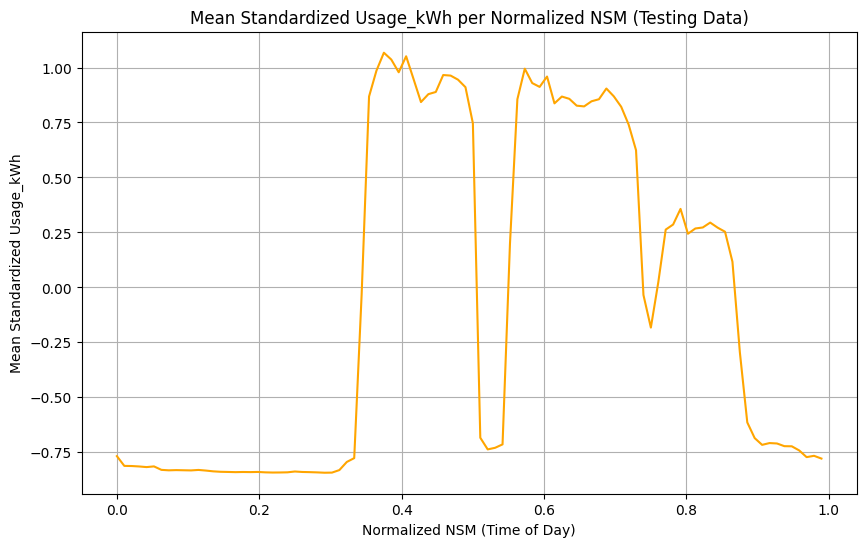

In [9]:
mean_Y_test_by_X = pd.DataFrame({'X_test': X_test, 'Y_test': Y_test}).groupby('X_test')['Y_test'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x='X_test', y='Y_test', data=mean_Y_test_by_X, color='orange')
plt.title('Mean Standardized Usage_kWh per Normalized NSM (Testing Data)')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Mean Standardized Usage_kWh')
plt.grid(True)
plt.show()


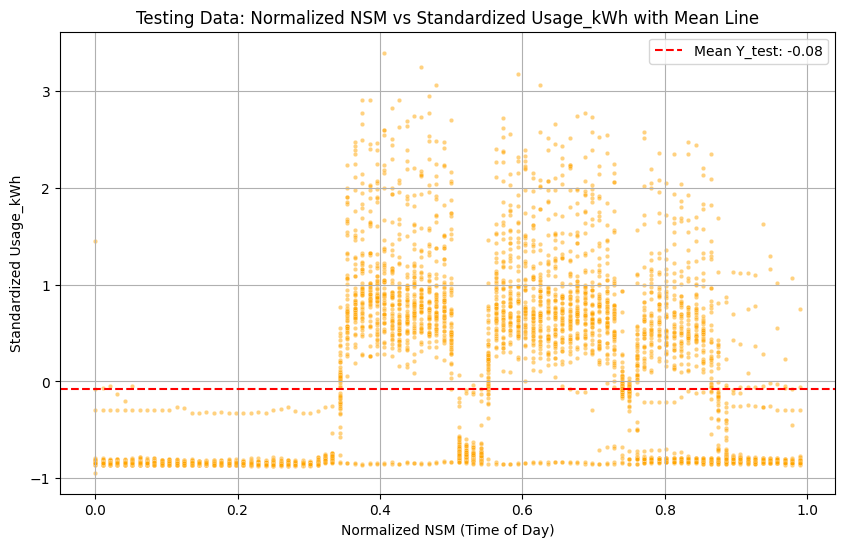

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test, y=Y_test, alpha=0.5, s=10, color='orange')
plt.axhline(y=Y_test.mean(), color='red', linestyle='--', label=f'Mean Y_test: {Y_test.mean():.2f}')
plt.title('Testing Data: Normalized NSM vs Standardized Usage_kWh with Mean Line')
plt.xlabel('Normalized NSM (Time of Day)')
plt.ylabel('Standardized Usage_kWh')
plt.grid(True)
plt.legend()
plt.show()


In [11]:
daily_variance_Y_by_NSM = df.groupby('NSM')['Usage_kWh'].var().reset_index()

print("Variance of Y (Usage_kWh) per NSM:")
display(daily_variance_Y_by_NSM.head())
print(f"Mean of NSM-grouped Usage_kWh variance: {daily_variance_Y_by_NSM['Usage_kWh'].mean():.2f}")

Variance of Y (Usage_kWh) per NSM:


,NSM,Usage_kWh
0,0,274.751678
1,900,227.563951
2,1800,283.666961
3,2700,247.159027
4,3600,271.164953


Mean of NSM-grouped Usage_kWh variance: 610.06


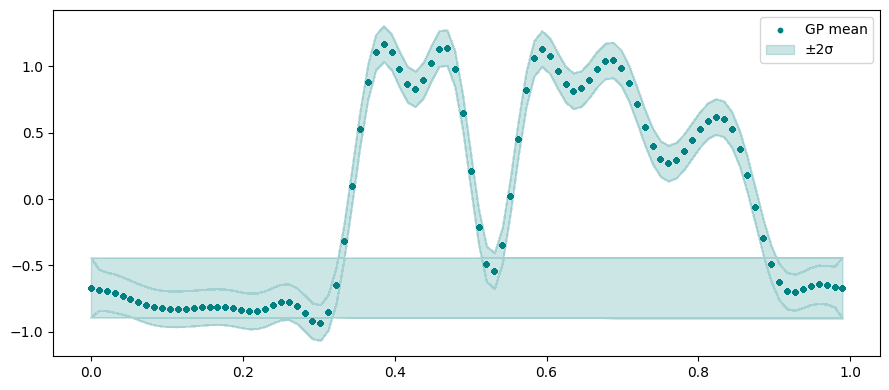

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def rbf(X1, X2, ls=1.0, sv=1.0):
    """Squared-exponential kernel. Returns (n1, n2) matrix."""
    sq = (np.sum(X1**2, 1, keepdims=True)
          + np.sum(X2**2, 1)
          - 2 * X1 @ X2.T)
    return sv * np.exp(-0.5 * sq / ls**2)

# ─────────────────────────────────────────────
# 2. FITC Sparse GP
# ─────────────────────────────────────────────
def fitc_predict(X_train, y_train, Z, X_star,
                 ls=1.0, sv=1.0, noise=0.1):
    """
    FITC sparse GP prediction.

    X_train : (n, d)   training inputs
    y_train : (n,)     training targets
    Z       : (m, d)   inducing inputs  ← the key ingredient
    X_star  : (n*, d)  test inputs
    """
    n, m = len(X_train), len(Z)

    # ── Step 1: build the three kernel matrices ──────────────
    K_mm = rbf(Z,       Z,       ls, sv)          # (m, m)
    K_nm = rbf(X_train, Z,       ls, sv)          # (n, m)
    K_ms = rbf(Z,       X_star,  ls, sv)          # (m, n*)
    K_nn_diag = sv * np.ones(n)                   # diag(K_nn), shape (n,)

    # ── Step 2: Cholesky of K_mm for stable solves ───────────
    jitter = 1e-6
    L_m = np.linalg.cholesky(K_mm + jitter * np.eye(m))  # (m, m)

    # ── Step 3: low-rank approximation Q_nn ──────────────────
    # Q_nn = K_nm @ K_mm^{-1} @ K_mn
    # We don't build Q_nn explicitly (that's n×n — too big).
    # Instead we compute the diagonal only: diag(Q_nn).
    #
    # diag(K_nm @ K_mm^{-1} @ K_mn)[i] = ||L_m^{-1} K_mn[:,i]||^2

    A = np.linalg.solve(L_m, K_nm.T)             # (m, n)  = L_m^{-1} K_mn
    Q_nn_diag = np.sum(A**2, axis=0)             # (n,)

    # ── Step 4: FITC noise term ───────────────────────────────
    # Each training point gets its own effective noise:
    # Λ = diag(K_nn - Q_nn) + σ_n² I
    # This is the "residual" variance not captured by inducing pts.

    Lambda = (K_nn_diag - Q_nn_diag) + noise     # (n,)  diagonal only

    # ── Step 5: build Σ = K_mm + K_mn Λ^{-1} K_nm  (Woodbury) ─
    # This is the (m,m) matrix we actually invert.

    B = K_nm.T / Lambda[np.newaxis, :]            # (m, n)  = K_mn @ Λ^{-1}
    Sigma = K_mm + B @ K_nm                       # (m, m)  — only m×m inversion!
    Sigma += jitter * np.eye(m)

    L_sigma = np.linalg.cholesky(Sigma)           # (m, m)

    # ── Step 6: compute alpha = Σ^{-1} K_mn Λ^{-1} y ────────
    rhs   = B @ y_train                           # (m,)
    alpha = np.linalg.solve(L_sigma.T,
              np.linalg.solve(L_sigma, rhs))      # (m,)

    # ── Step 7: posterior mean ────────────────────────────────
    mu_star = K_ms.T @ alpha                      # (n*,)

    # ── Step 8: posterior variance ────────────────────────────
    # Var[f*] = K_ss - K_sm K_mm^{-1} K_ms
    #                + K_sm Σ^{-1} K_ms
    # (first term = prior var; second = subtracted by inducing pts;
    #  third = added back from uncertainty in u)

    K_ss_diag = sv * np.ones(len(X_star))        # prior diag

    V1 = np.linalg.solve(L_m,     K_ms)          # (m, n*)
    V2 = np.linalg.solve(L_sigma, K_ms)          # (m, n*)

    var_star = K_ss_diag - np.sum(V1**2, 0) + np.sum(V2**2, 0)
    std_star = np.sqrt(np.maximum(var_star, 0))

    return mu_star, std_star


# ── 3. Run it ──────────────────────────────────────────────────
np.random.seed(42)

X_train_final = np.asarray(X_train_raw).reshape(-1, 1) # Reshape for rbf function
X_test_final  = np.asarray(X_test_raw).reshape(-1, 1)   # Reshape for rbf function
Y_train_final = np.asarray((Y_train_raw - Y_mean) / Y_std)

# Define inducing points Z
num_inducing_points = 100 # You can adjust this number
np.random.seed(0) # For reproducibility
# Select random indices for inducing points from the training data
idx = np.random.choice(len(X_train_final), num_inducing_points, replace=False)
Z = X_train_final[idx] # Inducing points

mu, std = fitc_predict(X_train_final, Y_train_final, Z, X_test_final,
                      ls=0.05, sv=1.0, noise=4)

# ── 4. Plot ───────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.scatter(X_test_final, mu, color='teal',   s=10, label='GP mean') # Changed to scatter
plt.fill_between(X_test_final.ravel(),
                 mu - 2*std, mu + 2*std,
                 alpha=0.2, color='teal', label='±2σ')
# plt.scatter(X_train_final, Y_train_final, color='crimson', s=10, zorder=5, label='Training points') # Use X_train_final and Y_train_final
plt.legend(); plt.tight_layout(); plt.show()